In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q imagehash timm

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.1 MB/s eta 0:00:00


In [ ]:
import hashlib, json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import numpy as np, pandas as pd, torch, timm, imagehash
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR  = Path('/content/drive/MyDrive/Indian_Food_Research')
DATASET_PATH = PROJECT_DIR / 'datasets' / 'CompressedDataset'
SPLITS_DIR, REPORTS_DIR = PROJECT_DIR / 'splits', PROJECT_DIR / 'reports'
SPLITS_DIR.mkdir(exist_ok=True); REPORTS_DIR.mkdir(exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PHASH_FLAG_MAX_DIST = 6
EMB_FLAG_MIN_SIM    = 0.95

full_ds = datasets.ImageFolder(str(DATASET_PATH))
assert len(full_ds.classes) == 100 and len(full_ds.samples) == 4578, ''
N = len(full_ds.samples)
paths  = [p for p, _ in full_ds.samples]
labels = np.array(full_ds.targets)

CACHE = REPORTS_DIR / 'dedup_cache.npz'
if CACHE.exists():
    z = np.load(CACHE, allow_pickle=False)
    MD5S, BITS, EMB = list(z['md5']), z['bits'], z['emb']
    assert len(MD5S) == N
    print('loaded hashes/embeddings from cache')
else:
    def md5(p):
        h = hashlib.md5()
        with open(p, 'rb') as f:
            for b in iter(lambda: f.read(1 << 20), b''):
                h.update(b)
        return h.hexdigest()
    def phash_bits(p):
        with Image.open(p) as im:
            return np.asarray(imagehash.phash(im.convert('RGB'), hash_size=8).hash, dtype=np.uint8).ravel()
    with ThreadPoolExecutor(16) as ex:
        MD5S = list(tqdm(ex.map(md5, paths), total=N, desc='md5'))
    with ThreadPoolExecutor(16) as ex:
        BITS = np.stack(list(tqdm(ex.map(phash_bits, paths), total=N, desc='phash')))
    model = timm.create_model('vit_base_patch14_dinov2', pretrained=True, num_classes=0, img_size=224).to(DEVICE).eval()
    tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    class PathDS(Dataset):
        def __len__(self): return N
        def __getitem__(self, i): return tf(Image.open(paths[i]).convert('RGB'))
    feats = []
    with torch.no_grad():
        for x in tqdm(DataLoader(PathDS(), batch_size=64, num_workers=2), desc='embed'):
            feats.append(F.normalize(model(x.to(DEVICE)), dim=-1).cpu())
    EMB = torch.cat(feats).numpy().astype(np.float32)
    del model; torch.cuda.empty_cache()
    np.savez(CACHE, md5=np.array(MD5S), bits=BITS, emb=EMB)
    print('saved cache')

loaded hashes/embeddings from cache


In [ ]:
MD5S = [str(m) for m in MD5S]
labels = np.asarray(labels).astype(int)
df = pd.DataFrame({'idx': np.arange(N), 'path': [str(p) for p in paths], 'label': labels,
                   'class': [full_ds.classes[l] for l in labels], 'md5': MD5S})
assert df.columns.is_unique

exclude, reason = set(), {}
for h, g in df.groupby('md5', sort=False):
    if len(g) == 1:
        continue
    ids = [int(i) for i in g['idx']]
    if g['label'].nunique() > 1:
        for i in ids:
            exclude.add(i); reason[i] = 'exact duplicate under different classes'
    else:
        for i in ids[1:]:
            exclude.add(i); reason[i] = 'exact duplicate (same class)'

dup_rows = df[df['md5'].duplicated(keep=False)].copy()
dup_rows['removed'] = dup_rows['idx'].isin(list(exclude))
dup_rows['reason'] = [reason.get(int(i), 'kept (first copy)') for i in dup_rows['idx']]
dup_rows = dup_rows.sort_values('idx').sort_values('md5', kind='stable')      # single-key sorts only
dup_rows.to_csv(REPORTS_DIR / 'exact_duplicate_groups_all.csv', index=False)

keep = np.array([i not in exclude for i in range(N)])
D = np.empty((N, N), dtype=np.uint8)
for i in range(0, N, 256):
    D[i:i + 256] = (BITS[i:i + 256, None, :] != BITS[None, :, :]).sum(-1)
S = EMB @ EMB.T
near = ((D <= PHASH_FLAG_MAX_DIST) | (S >= EMB_FLAG_MIN_SIM)) & keep[:, None] & keep[None, :]
np.fill_diagonal(near, False)
ii, jj = np.where(np.triu(near, 1))

parent = list(range(N))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for a, b in zip(ii, jj):
    ra, rb = find(int(a)), find(int(b))
    if ra != rb:
        parent[rb] = ra
group_id = [find(i) for i in range(N)]

gsize = Counter(group_id[i] for i in range(N) if keep[i])
multi = {g: n for g, n in gsize.items() if n > 1}
mixed = [g for g in multi if len({int(labels[i]) for i in range(N) if keep[i] and group_id[i] == g}) > 1]

ng = pd.DataFrame([{'group': int(group_id[i]), 'idx': i, 'class': full_ds.classes[labels[i]], 'path': str(paths[i])}
                   for i in range(N) if keep[i] and group_id[i] in multi],
                  columns=['group', 'idx', 'class', 'path'])
ng = ng.sort_values('idx').sort_values('group', kind='stable')
ng.to_csv(REPORTS_DIR / 'near_duplicate_groups.csv', index=False)

(SPLITS_DIR / 'dedup_exclude.json').write_text(json.dumps(sorted(exclude)))
(SPLITS_DIR / 'group_ids.json').write_text(json.dumps([int(g) for g in group_id]))
dedup_summary = {
    'images_collected': int(N),
    'exact_duplicate_groups': int(dup_rows['md5'].nunique()),
    'removed_extra_copies_same_class': sum(r.startswith('exact duplicate (same') for r in reason.values()),
    'removed_cross_class_duplicates': sum(r.startswith('exact duplicate under') for r in reason.values()),
    'images_used': int(keep.sum()),
    'near_duplicate_groups_kept_together': len(multi),
    'images_in_near_duplicate_groups': int(sum(multi.values())),
    'largest_group': int(max(multi.values())) if multi else 1,
    'near_duplicate_groups_spanning_classes': len(mixed),
    'thresholds': {'phash_hamming_max': PHASH_FLAG_MAX_DIST, 'dinov2_cosine_min': EMB_FLAG_MIN_SIM},
    'per_class_used_min': int(np.bincount(labels[keep], minlength=100).min())}
(REPORTS_DIR / 'dedup_summary.json').write_text(json.dumps(dedup_summary, indent=2))
print(json.dumps(dedup_summary, indent=2))
assert dedup_summary['per_class_used_min'] >= 3, 'a class has <3 images left; it cannot appear in train, val and test'

{
  "images_collected": 4578,
  "exact_duplicate_groups": 84,
  "removed_extra_copies_same_class": 73,
  "removed_cross_class_duplicates": 22,
  "images_used": 4483,
  "near_duplicate_groups_kept_together": 210,
  "images_in_near_duplicate_groups": 497,
  "largest_group": 17,
  "near_duplicate_groups_spanning_classes": 3,
  "thresholds": {
    "phash_hamming_max": 6,
    "dinov2_cosine_min": 0.95
  },
  "per_class_used_min": 7
}


In [ ]:
import hashlib, json, pickle
from pathlib import Path
import numpy as np, pandas as pd, torch, timm
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR  = Path('/content/drive/MyDrive/Indian_Food_Research')
DATASET_PATH = PROJECT_DIR / 'datasets' / 'CompressedDataset'
SPLITS_DIR   = PROJECT_DIR / 'splits'
REPORTS_DIR  = PROJECT_DIR / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# thresholds used for the FLAG list
PHASH_FLAG_MAX_DIST = 6
EMB_FLAG_MIN_SIM    = 0.95

full_ds = datasets.ImageFolder(str(DATASET_PATH))
assert len(full_ds.classes) == 100 and len(full_ds.samples) == 4578, ''
train_idx = pickle.load(open(SPLITS_DIR / 'train_idx.pkl', 'rb'))
val_idx   = pickle.load(open(SPLITS_DIR / 'val_idx.pkl',   'rb'))
test_idx  = pickle.load(open(SPLITS_DIR / 'test_idx.pkl',  'rb'))

N = len(full_ds.samples)
paths  = [p for p, _ in full_ds.samples]
labels = np.array(full_ds.targets)
split_of = np.array([''] * N, dtype=object)
for name, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    split_of[list(idx)] = name
split_of[split_of == ''] = 'excluded'
print('excluded (not in any split):', int((split_of == 'excluded').sum()))
print({s: int((split_of == s).sum()) for s in ['train', 'val', 'test', 'excluded']})

excluded (not in any split): 95
{'train': 3127, 'val': 678, 'test': 678, 'excluded': 95}


In [ ]:
def md5(p, chunk=1 << 20):
    h = hashlib.md5()
    with open(p, 'rb') as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

md5s = MD5S
df = pd.DataFrame({'idx': np.arange(N), 'path': paths, 'label': labels,
                   'class': [full_ds.classes[l] for l in labels], 'split': split_of, 'md5': md5s})

df = df[df.split != 'excluded']
dup_groups = df.groupby('md5').filter(lambda g: len(g) > 1)
cross_split = dup_groups.groupby('md5').filter(lambda g: g['split'].nunique() > 1)
cross_class = dup_groups.groupby('md5').filter(lambda g: g['label'].nunique() > 1)

other_hashes = set(df.loc[df.split != 'test', 'md5'])
test_exact = df[(df.split == 'test') & df.md5.isin(other_hashes)]
val_hashes = set(df.loc[df.split == 'train', 'md5'])
val_exact = df[(df.split == 'val') & df.md5.isin(val_hashes)]

exact_summary = {
    'files_in_exact_duplicate_groups': int(len(dup_groups)),
    'exact_duplicate_groups': int(dup_groups.md5.nunique()),
    'groups_spanning_more_than_one_split': int(cross_split.md5.nunique()),
    'test_images_with_exact_copy_in_train_or_val': int(len(test_exact)),
    'val_images_with_exact_copy_in_train': int(len(val_exact)),
    'groups_spanning_more_than_one_class': int(cross_class.md5.nunique()),
}
print(json.dumps(exact_summary, indent=2))
dup_groups.sort_values('md5').to_csv(REPORTS_DIR / 'exact_duplicate_files.csv', index=False)

{
  "files_in_exact_duplicate_groups": 0,
  "exact_duplicate_groups": 0,
  "groups_spanning_more_than_one_split": 0,
  "test_images_with_exact_copy_in_train_or_val": 0,
  "val_images_with_exact_copy_in_train": 0,
  "groups_spanning_more_than_one_class": 0
}


In [ ]:
def phash_bits(p):
    with Image.open(p) as im:
        h = imagehash.phash(im.convert('RGB'), hash_size=8)
    return np.asarray(h.hash, dtype=np.uint8).ravel()

bits = BITS

D = np.empty((N, N), dtype=np.uint8)
for i in range(0, N, 256):
    D[i:i + 256] = (bits[i:i + 256, None, :] != bits[None, :, :]).sum(-1)
np.fill_diagonal(D, 64)

is_test, is_val, is_train = (split_of == 'test'), (split_of == 'val'), (split_of == 'train')

def count_with_match(M, rows_mask, cols_mask, thr, smaller_is_closer=True):
    sub = M[np.ix_(rows_mask, cols_mask)]
    hit = (sub <= thr) if smaller_is_closer else (sub >= thr)
    return int(hit.any(1).sum())

ph_rows = []
for thr in [0, 2, 4, 6, 8, 10]:
    ph_rows.append({'pHash Hamming <=': thr,
                    'test imgs w/ match in train': count_with_match(D, is_test, is_train, thr),
                    'test imgs w/ match in val':   count_with_match(D, is_test, is_val, thr),
                    'val imgs w/ match in train':  count_with_match(D, is_val, is_train, thr)})
ph_table = pd.DataFrame(ph_rows)
ph_table.to_csv(REPORTS_DIR / 'phash_threshold_sweep.csv', index=False)
ph_table

,pHash Hamming <=,test imgs w/ match in train,test imgs w/ match in val,val imgs w/ match in train
0,0,0,0,0
1,2,0,0,0
2,4,0,0,0
3,6,0,0,0
4,8,4,3,2
5,10,15,8,13


In [ ]:
E = torch.from_numpy(EMB)
S = (E @ E.T).numpy()
np.fill_diagonal(S, -1.0)

em_rows = []
for thr in [0.90, 0.93, 0.95, 0.97, 0.98, 0.99]:
    em_rows.append({'cosine >=': thr,
                    'test imgs w/ match in train': count_with_match(S, is_test, is_train, thr, False),
                    'test imgs w/ match in val':   count_with_match(S, is_test, is_val, thr, False),
                    'val imgs w/ match in train':  count_with_match(S, is_val, is_train, thr, False)})
em_table = pd.DataFrame(em_rows)
em_table.to_csv(REPORTS_DIR / 'embedding_threshold_sweep.csv', index=False)
em_table

,cosine >=,test imgs w/ match in train,test imgs w/ match in val,val imgs w/ match in train
0,0.90,256,111,209
1,0.93,103,29,72
2,0.95,0,0,0
3,0.97,0,0,0
4,0.98,0,0,0
5,0.99,0,0,0


same-class share among the 300 closest cross-split pairs: 1.0


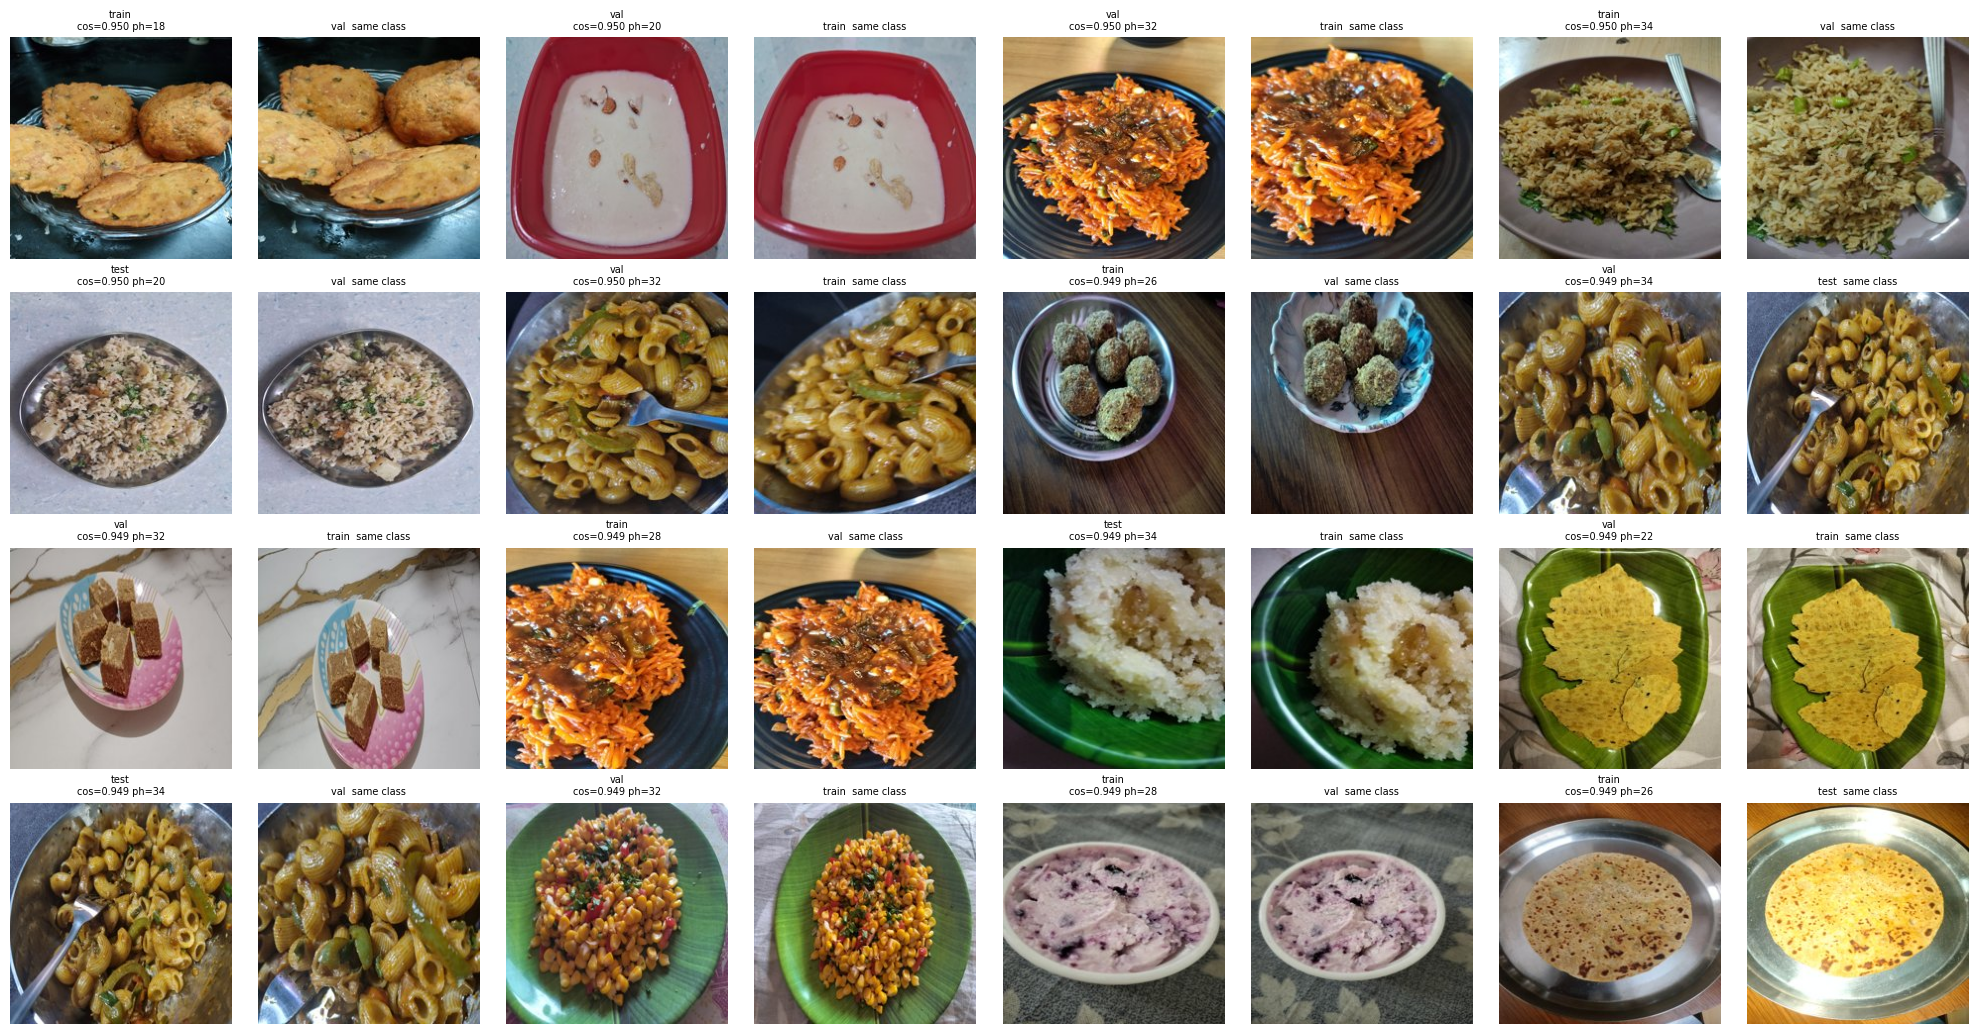

In [ ]:
used_ = split_of != 'excluded'
cross = (split_of[:, None] != split_of[None, :]) & used_[:, None] & used_[None, :]
iu = np.triu_indices(N, k=1)
mask = cross[iu]
ii, jj = iu[0][mask], iu[1][mask]
sims = S[ii, jj]
order = np.argsort(-sims)[:300]
top = pd.DataFrame({'i': ii[order], 'j': jj[order], 'cosine': sims[order],
                    'phash_dist': D[ii[order], jj[order]]})
top['split_i'], top['split_j'] = split_of[top.i], split_of[top.j]
top['class_i'], top['class_j'] = [full_ds.classes[l] for l in labels[top.i]], [full_ds.classes[l] for l in labels[top.j]]
top['same_class'] = top.class_i == top.class_j
top['path_i'], top['path_j'] = [paths[k] for k in top.i], [paths[k] for k in top.j]
top.to_csv(REPORTS_DIR / 'closest_cross_split_pairs.csv', index=False)
print('same-class share among the 300 closest cross-split pairs:', round(top.same_class.mean(), 3))

def show_pairs(rows, ncols=4):
    n = len(rows); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(ncols * 5, nrows * 2.6))
    axes = np.atleast_2d(axes)
    for a in axes.ravel(): a.axis('off')
    for k, (_, r) in enumerate(rows.iterrows()):
        a1, a2 = axes[k // ncols, (k % ncols) * 2], axes[k // ncols, (k % ncols) * 2 + 1]
        a1.imshow(Image.open(r.path_i)); a2.imshow(Image.open(r.path_j))
        a1.set_title(f'{r.split_i}\ncos={r.cosine:.3f} ph={r.phash_dist}', fontsize=7)
        a2.set_title(f'{r.split_j}  {"same" if r.same_class else "DIFF"} class', fontsize=7)
    plt.tight_layout(); plt.show()

show_pairs(top.head(16))

300 pairs within the band around EMB_FLAG_MIN_SIM


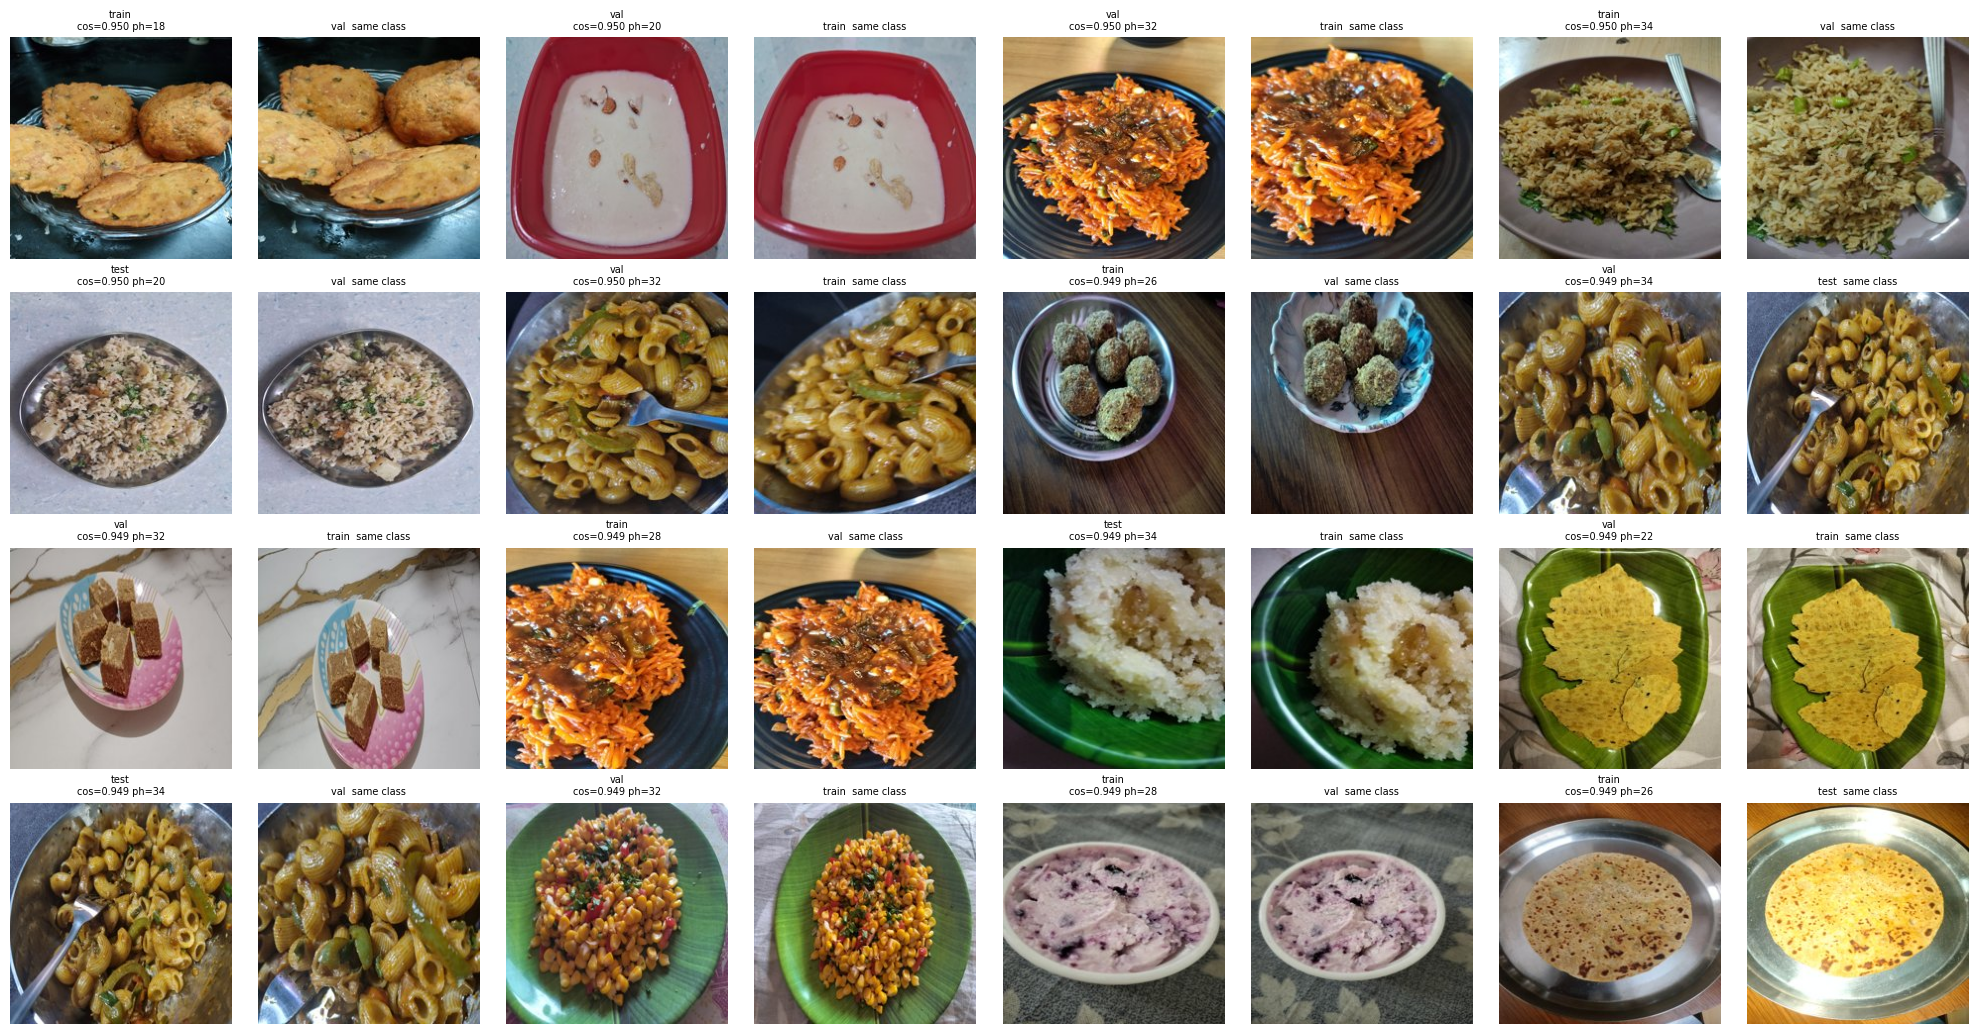

In [ ]:
band = top[(top.cosine < EMB_FLAG_MIN_SIM + 0.02) & (top.cosine > EMB_FLAG_MIN_SIM - 0.05)]
print(len(band), 'pairs within the band around EMB_FLAG_MIN_SIM')
show_pairs(band.head(16))

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import json, pickle, shutil, numpy as np
from pathlib import Path

P = Path('/content/drive/MyDrive/Indian_Food_Research')
assert (P / 'datasets' / 'CompressedDataset').is_dir(), 'WRONG DRIVE MOUNTED'
SPL, REP, PKG = P / 'splits', P / 'reports', P / 'repro_package'

z = np.load(REP / 'dedup_cache.npz', allow_pickle=False)
md5, bits, emb = np.array([str(m) for m in z['md5']]), z['bits'], z['emb']
N = len(md5)
tr, va, te = (pickle.load(open(SPL / f, 'rb')) for f in ['train_idx.pkl', 'val_idx.pkl', 'test_idx.pkl'])
split = np.array(['excluded'] * N, dtype=object)
split[list(tr)], split[list(va)], split[list(te)] = 'train', 'val', 'test'

ti = np.where(split == 'test')[0]
oi = np.where((split == 'train') | (split == 'val'))[0]
exact = np.isin(md5[ti], md5[oi])
ph = np.zeros(len(ti), bool)
for k in range(0, len(ti), 64):
    ph[k:k+64] = ((bits[ti[k:k+64]][:, None, :] != bits[oi][None, :, :]).sum(-1) <= 6).any(1)
em = ((emb[ti] @ emb[oi].T) >= 0.95).any(1)
flagged = sorted(int(i) for i in ti[exact | ph | em])

summary = json.loads((REP / 'duplicate_audit_summary.json').read_text()) if (REP / 'duplicate_audit_summary.json').exists() else {}
summary.update({'compared_against': 'train + val images only (removed duplicate copies excluded)',
                'phash_flag_max_dist': 6, 'embedding_flag_min_sim': 0.95,
                'test_images_with_exact_copy_in_train_or_val': int(exact.sum()),
                'test_images_flagged_by_phash': int(ph.sum()), 'test_images_flagged_by_embedding': int(em.sum()),
                'test_images_flagged_any': len(flagged), 'test_size': int(len(ti))})
(REP / 'duplicate_audit_summary.json').write_text(json.dumps(summary, indent=2))
(SPL / 'flagged_test_indices.json').write_text(json.dumps(flagged))
for f in [REP / 'duplicate_audit_summary.json', SPL / 'flagged_test_indices.json']:
    shutil.copy(f, PKG / f.name)
print(json.dumps(summary, indent=2))

Mounted at /content/drive
{
  "files_in_exact_duplicate_groups": 0,
  "exact_duplicate_groups": 0,
  "groups_spanning_more_than_one_split": 0,
  "test_images_with_exact_copy_in_train_or_val": 0,
  "val_images_with_exact_copy_in_train": 0,
  "groups_spanning_more_than_one_class": 0,
  "phash_flag_max_dist": 6,
  "embedding_flag_min_sim": 0.95,
  "test_images_flagged_by_phash": 0,
  "test_images_flagged_by_embedding": 0,
  "test_images_flagged_any": 0,
  "test_size": 678,
  "compared_against": "train + val images only (removed duplicate copies excluded)"
}
